In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile



In [2]:

orig_dir = '/content/'
base_dir = orig_dir + '/augmented_data_set_final/OriginalDataset/'

In [3]:
zip_file = orig_dir + 'original_dataset_alz.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(orig_dir)

Epoch 1/100
120/120 - 86s - loss: 0.7918 - accuracy: 0.5891 - auc: 0.6214 - val_loss: 0.6462 - val_accuracy: 0.6617 - val_auc: 0.7346 - lr: 1.0000e-04 - 86s/epoch - 717ms/step
Epoch 2/100
120/120 - 79s - loss: 0.6816 - accuracy: 0.6461 - auc: 0.7035 - val_loss: 0.6245 - val_accuracy: 0.6672 - val_auc: 0.7496 - lr: 1.0000e-04 - 79s/epoch - 659ms/step
Epoch 3/100
120/120 - 79s - loss: 0.6615 - accuracy: 0.6693 - auc: 0.7217 - val_loss: 0.6041 - val_accuracy: 0.6687 - val_auc: 0.7662 - lr: 1.0000e-04 - 79s/epoch - 655ms/step
Epoch 4/100
120/120 - 80s - loss: 0.6473 - accuracy: 0.6620 - auc: 0.7243 - val_loss: 0.5684 - val_accuracy: 0.7055 - val_auc: 0.7785 - lr: 1.0000e-04 - 80s/epoch - 667ms/step
Epoch 5/100
120/120 - 80s - loss: 0.6266 - accuracy: 0.6727 - auc: 0.7387 - val_loss: 0.6599 - val_accuracy: 0.6617 - val_auc: 0.7658 - lr: 1.0000e-04 - 80s/epoch - 668ms/step
Epoch 6/100
120/120 - 81s - loss: 0.6240 - accuracy: 0.6708 - auc: 0.7400 - val_loss: 0.5592 - val_accuracy: 0.7164 - va

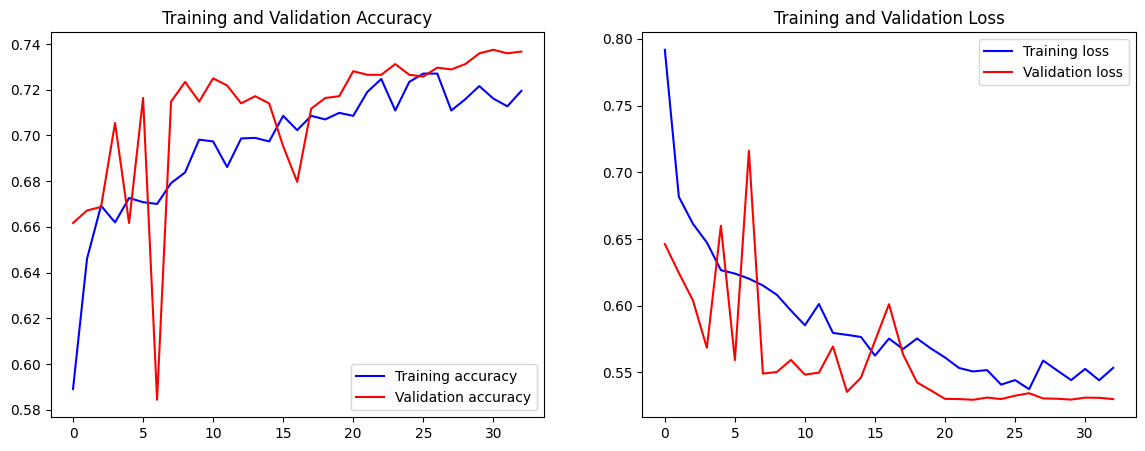

40/40 [==============================] - 10s 243ms/step - loss: 0.5225 - accuracy: 0.7398 - auc: 0.8208
Test accuracy: 0.74, Test AUC: 0.82


In [ ]:


def load_images_and_labels(base_dir, target_size=(299, 299)):
    images, labels = [], []
    for category in os.listdir(base_dir):
        if category in ['MildDemented', 'ModerateDemented', 'VeryMildDemented']:
            class_label = 1
        elif category == 'NonDemented':
            class_label = 0
        else:
            continue
        category_dir = os.path.join(base_dir, category)
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            img = load_img(file_path, target_size=target_size)
            img = img_to_array(img)
            img /= 255.0
            images.append(img)
            labels.append(class_label)
    return np.array(images), np.array(labels)

images, labels = load_images_and_labels(base_dir)


train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.25, random_state=42) # 0.25 x 0.8 = 0.2


class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(class_weights))


data_augmentation = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


def create_model(input_shape):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False


    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model


model = create_model((299, 299, 3))
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])


callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1),
    #ModelCheckpoint(filepath='data/best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]


history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    validation_data=(valid_images, valid_labels),
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=2
)


def plot_training_history(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_training_history(history)


test_loss, test_accuracy, test_auc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_accuracy:.2f}, Test AUC: {test_auc:.2f}')


40/40 [==============================] - 10s 228ms/step


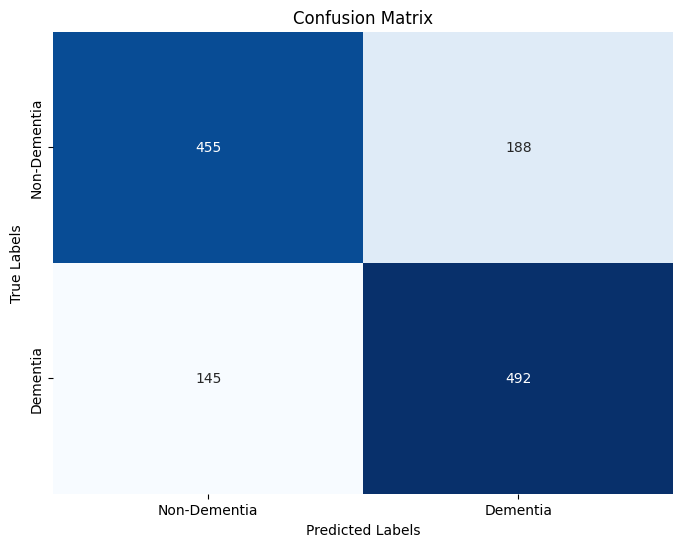

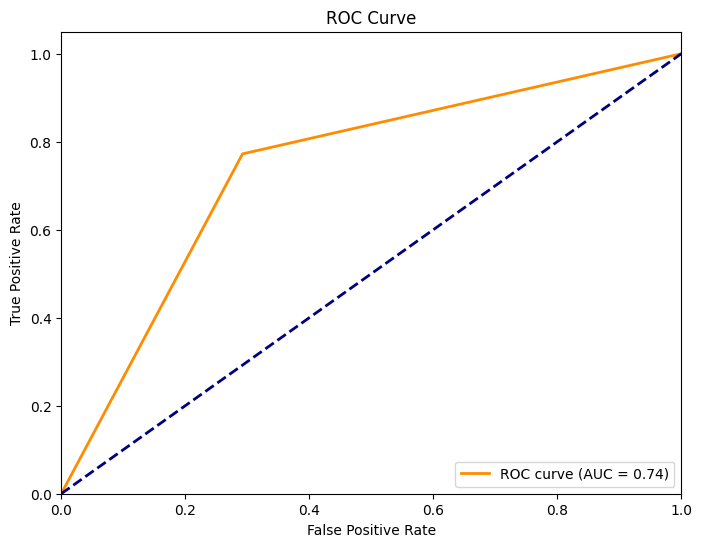

In [ ]:
test_predictions = model.predict(test_images)
test_predictions = (test_predictions > 0.5).astype(int)
conf_matrix = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Dementia', 'Dementia'],
            yticklabels=['Non-Dementia', 'Dementia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr, tpr, thresholds = roc_curve(test_labels, test_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

83683744/83683744 [==============================] - 5s 0us/step
Epoch 1/100
120/120 - 58s - loss: 3.0912 - accuracy: 0.6068 - auc: 0.6475 - val_loss: 2.8076 - val_accuracy: 0.6656 - val_auc: 0.7732 - lr: 1.0000e-04 - 58s/epoch - 486ms/step
Epoch 2/100
120/120 - 44s - loss: 2.8173 - accuracy: 0.6479 - auc: 0.7035 - val_loss: 2.6130 - val_accuracy: 0.6750 - val_auc: 0.7455 - lr: 1.0000e-04 - 44s/epoch - 364ms/step
Epoch 3/100
120/120 - 43s - loss: 2.5977 - accuracy: 0.6510 - auc: 0.7203 - val_loss: 2.4152 - val_accuracy: 0.6945 - val_auc: 0.7786 - lr: 1.0000e-04 - 43s/epoch - 360ms/step
Epoch 4/100
120/120 - 43s - loss: 2.4155 - accuracy: 0.6771 - auc: 0.7383 - val_loss: 2.2937 - val_accuracy: 0.6852 - val_auc: 0.7690 - lr: 1.0000e-04 - 43s/epoch - 362ms/step
Epoch 5/100
120/120 - 43s - loss: 2.2768 - accuracy: 0.6826 - auc: 0.7404 - val_loss: 2.1371 - val_accuracy: 0.7109 - val_auc: 0.7849 - lr: 1.0000e-04 - 43s/epoch - 361ms/step
Epoch 6/100
120/120 - 44s - loss: 2.1436 - accuracy: 0.

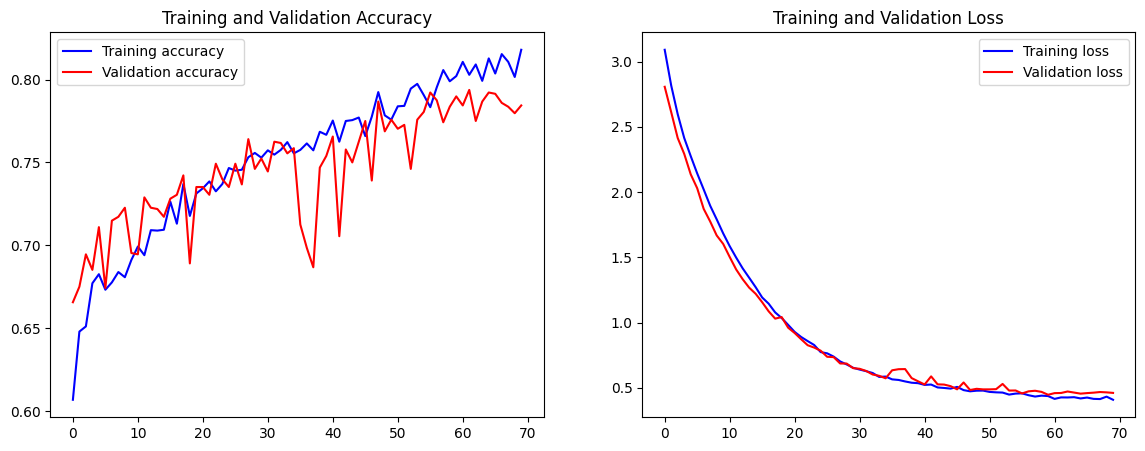

40/40 [==============================] - 5s 132ms/step - loss: 0.4694 - accuracy: 0.7773 - auc: 0.8686
Test accuracy: 0.78, Test AUC: 0.87


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import zipfile

def load_images_and_labels(base_dir, target_size=(224, 224)):
    images, labels = [], []
    for category in os.listdir(base_dir):
        class_label = 1 if category in ['MildDemented', 'ModerateDemented', 'VeryMildDemented'] else 0 if category == 'NonDemented' else None
        if class_label is None:
            continue
        category_dir = os.path.join(base_dir, category)
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            img = load_img(file_path, target_size=target_size)
            img = img_to_array(img)
            img /= 255.0
            images.append(img)
            labels.append(class_label)
    return np.array(images), np.array(labels)

images, labels = load_images_and_labels(base_dir)

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.25, random_state=42)

# Let's address any class imbalances
# https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(class_weights))

data_augmentation = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.25,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)


def create_model(input_shape):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True
    for layer in base_model.layers[:-8]:
        layer.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

model = create_model((224, 224, 3))
model.compile(optimizer=Nadam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])


callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1),
    #ModelCheckpoint(filepath='data/best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]


history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    validation_data=(valid_images, valid_labels),
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=2
)


def plot_training_history(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_training_history(history)


test_loss, test_accuracy, test_auc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_accuracy:.2f}, Test AUC: {test_auc:.2f}')


40/40 [==============================] - 5s 129ms/step


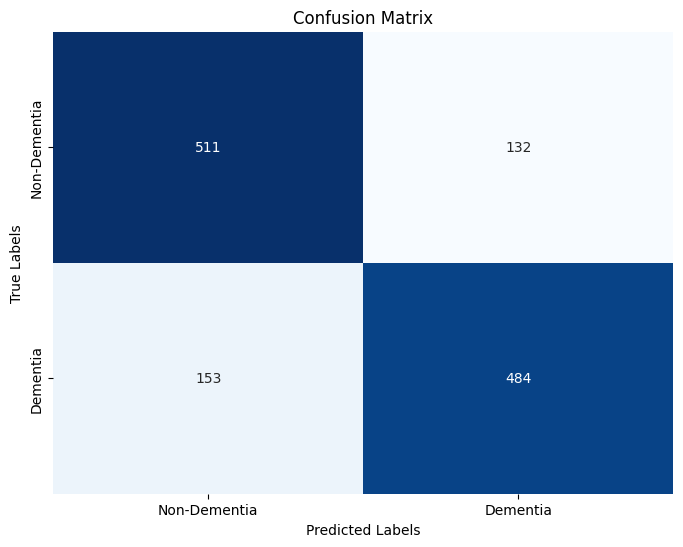

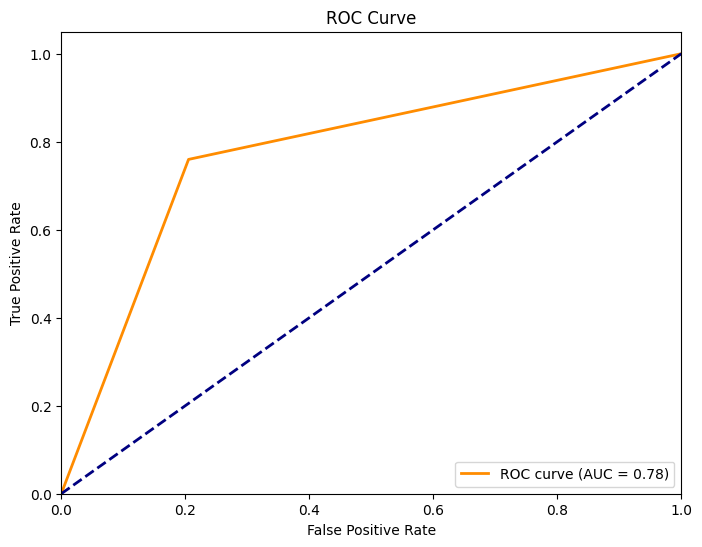

In [ ]:

test_predictions = model.predict(test_images)
test_predictions = (test_predictions > 0.5).astype(int)
conf_matrix = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Dementia', 'Dementia'],
            yticklabels=['Non-Dementia', 'Dementia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr, tpr, thresholds = roc_curve(test_labels, test_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

83683744/83683744 [==============================] - 5s 0us/step
Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 - 56s - loss: 5.1425 - accuracy: 0.6328 - auc: 0.6837 - val_loss: 4.7670 - val_accuracy: 0.6812 - val_auc: 0.7609 - lr: 1.0000e-04 - 56s/epoch - 463ms/step
Epoch 2/150
120/120 - 41s - loss: 4.6619 - accuracy: 0.6719 - auc: 0.7404 - val_loss: 4.3755 - val_accuracy: 0.6922 - val_auc: 0.7725 - lr: 1.0000e-04 - 41s/epoch - 338ms/step
Epoch 3/150
120/120 - 41s - loss: 4.2590 - accuracy: 0.7000 - auc: 0.7801 - val_loss: 4.0349 - val_accuracy: 0.7133 - val_auc: 0.8265 - lr: 1.0000e-04 - 41s/epoch - 339ms/step
Epoch 4/150
120/120 - 42s - loss: 3.9127 - accuracy: 0.7143 - auc: 0.8009 - val_loss: 3.7185 - val_accuracy: 0.7211 - val_auc: 0.8261 - lr: 1.0000e-04 - 42s/epoch - 346ms/step
Epoch 5/150
120/120 - 41s - loss: 3.6074 - accuracy: 0.7323 - auc: 0.8120 - val_loss: 3.4398 - val_accuracy: 0.7211 - val_auc: 0.8278 - lr: 1.0000e-04 - 41s/epoch - 345ms/step
Epoch 6/150
120/120 - 41s - loss: 3.2969 - accuracy: 0.7570 - auc: 0.8406 - val_loss: 3.1356 - val_accuracy: 0.7555 - val_auc: 0.855

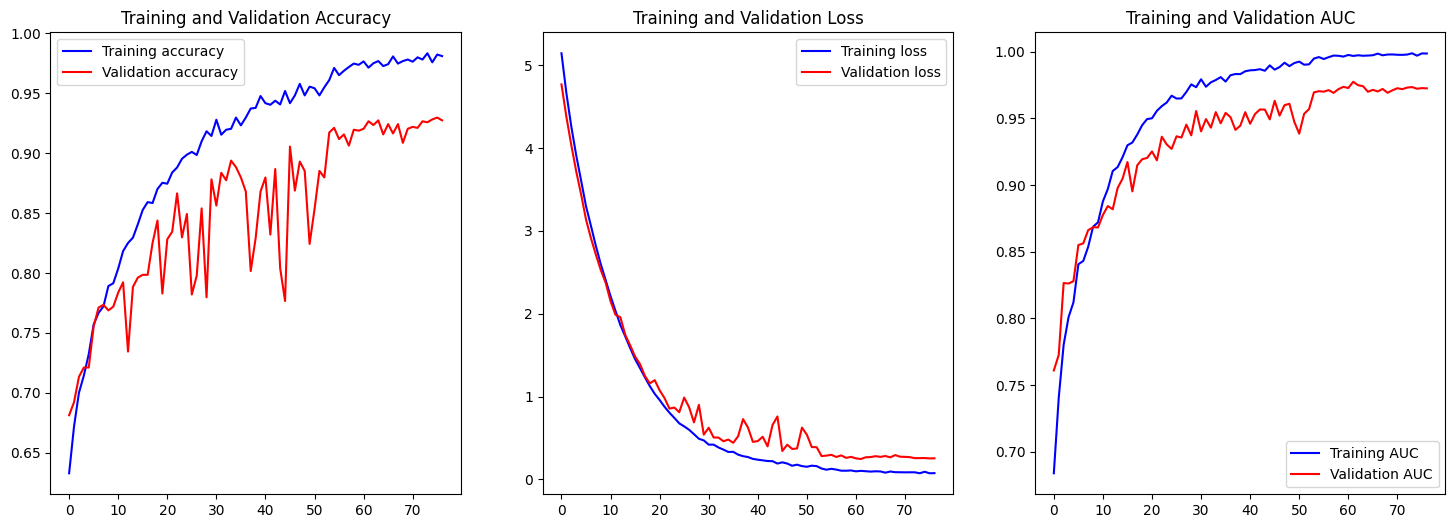

40/40 [==============================] - 5s 122ms/step - loss: 0.2519 - accuracy: 0.9227 - auc: 0.9740
Test accuracy: 0.92, Test AUC: 0.97


In [4]:
# Model no 3, Final Attempt
# Stripped the augmentation right back so that it is not too aggressive  eg Zoom, shearing, vertical flip are removed, rotation reduced

# Slightly smaller size than what the Xception model was trained on ie 299 * 299
def load_images_and_labels(base_dir, target_size=(224, 224)):
    images, labels = [], []
    for category in os.listdir(base_dir):
        class_label = 1 if category in ['MildDemented', 'ModerateDemented', 'VeryMildDemented'] else 0 if category == 'NonDemented' else None
        if class_label is None:
            continue
        category_dir = os.path.join(base_dir, category) # Match the directory structure
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            img = load_img(file_path, target_size=target_size)
            img = img_to_array(img)
            img /= 255.0 # Scale images
            images.append(img)
            labels.append(class_label)
    return np.array(images), np.array(labels) # Need these stored as arrays


images, labels = load_images_and_labels(base_dir)
train_images_init, test_images, train_labels_init, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42) #Get an initial training set, create test set
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images_init, train_labels_init, test_size=0.25, random_state=42)# From initial training set, create true training and validation set

# Let's address any class imbalances
# https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(class_weights))

data_augmentation = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Set up Xception Model, freeze the earlier layers
def create_model(input_shape):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True
    for layer in base_model.layers[:-8]:
        layer.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(1, activation='sigmoid')
    ])
    return model

model = create_model((224, 224, 3))
model.compile(optimizer=Nadam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6),
    ModelCheckpoint(filepath='data/best_model.h5', save_best_only=True)
]

history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    validation_data=(valid_images, valid_labels),
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=2
)

def plot_training_history(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, accuracy, 'b', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 3, 3)
    train_auc = history.history['auc']
    val_auc = history.history['val_auc']
    plt.plot(epochs, train_auc, 'b', label='Training AUC')
    plt.plot(epochs, val_auc, 'r', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.legend()

    plt.show()

plot_training_history(history)

test_loss, test_accuracy, test_auc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_accuracy:.2f}, Test AUC: {test_auc:.2f}')



40/40 [==============================] - 5s 118ms/step


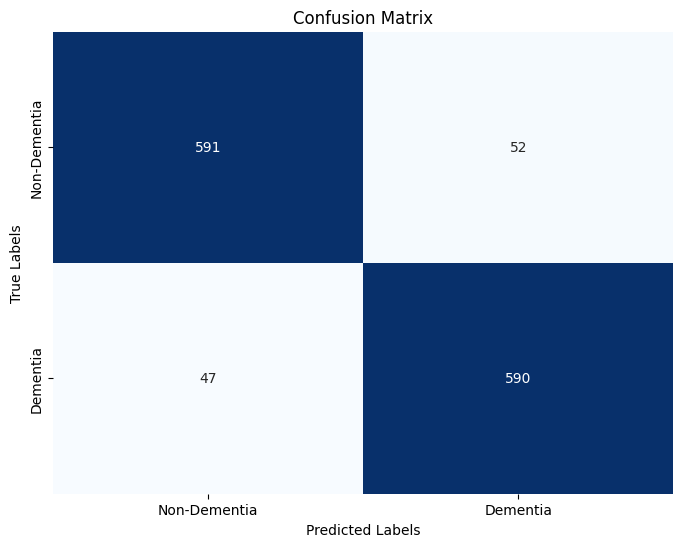

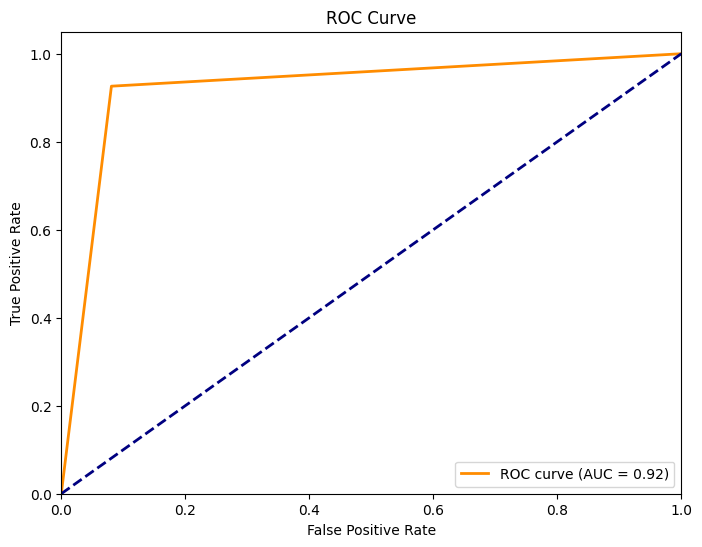

In [5]:

test_predictions = model.predict(test_images)
test_predictions = (test_predictions > 0.5).astype(int)
conf_matrix = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Dementia', 'Dementia'],
            yticklabels=['Non-Dementia', 'Dementia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr, tpr, thresholds = roc_curve(test_labels, test_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [8]:
print('Classification Report:')
print(classification_report(test_labels, test_predictions, target_names=['Non-Dementia', 'Dementia']))

Classification Report:
              precision    recall  f1-score   support

Non-Dementia       0.93      0.92      0.92       643
    Dementia       0.92      0.93      0.92       637

    accuracy                           0.92      1280
   macro avg       0.92      0.92      0.92      1280
weighted avg       0.92      0.92      0.92      1280

